In [1]:
#Import Libraries and Setup

import PKA_Sleep as PKA
from PKA_Sleep import Graphing_Utils as graph
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, ttest_1samp
import importlib
from scipy.signal import savgol_filter
import os
graph.make_bigandbold()
importlib.reload(PKA.AntagonistAnalyses)
importlib.reload(PKA.twomodel)
importlib.reload(PKA)

<module 'PKA_Sleep' from '/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/__init__.py'>

In [2]:
#Configure Experiment Parameters and Build FLP Classes

parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/'
epoch_len = 4
filter_bounds = [None, None]
binned = False
shuffle_window = 200
experimental_sensor = 'FLIM-mAKAR'
sleep_states = True
microarousals = True
seperate_acqs = False

# SD experiments (index 0) and control experiments (index 1)
EXP_NAMES = [
    [
        'kgFLiPAKAREEGEMG0018',
        'kgFLiPAKAREEGEMG0019',
        'kgFLiPAKAREEGEMG0020',
        'kgFLiPAKAREEGEMG0022',
        'kgFLiPAKAREEGEMG0023',
        'kgFLiPAKAREEGEMG0024'
    ],
    [
        'kgFLiPAKAREEGEMG0018',
        'kgFLiPAKAREEGEMG0019',
        'kgFLiPAKAREEGEMG0020',
        'kgFLiPAKAREEGEMG0022',
        'kgFLiPAKAREEGEMG0023',
        'kgFLiPAKAREEGEMG0024'
    ]
]
mouse_names = [
    ['5582', '5583','5577', '5576', '5580', '5710'],
    ['5582', '5583','5577', '5576', '5580', '5710']
]

# Build FLP classes
FLP_classes_dict = [
    PKA.build_classes(
        e, mouse_names[i], epoch_len=epoch_len, filter_bounds=filter_bounds,
        binned=binned, shuffle_window=shuffle_window, experimental_sensor=experimental_sensor,
        sleep_states=sleep_states, microarousals=microarousals, seperate_acqs=seperate_acqs,
        emp_lifetime=False, parent_data_directory=parent_data_directory, exclude_acqs=False
    )
    for i, e in enumerate(EXP_NAMES)
]

You didn't put any filter values
You didn't put any filter values
The following acquisisions are not sleep scored:
[np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(49), np.uint8(50)]
I will fill these with 0s
You didn't put any filter values
The following acquisisions are not sleep scored:
[np.uint8(49), np.uint8(50)]
I will fill these with 0s
You didn't put any filter values
The following acquisisions are not sleep scored:
[np.uint8(46), np.uint8(47), np.uint8(48), np.uint8(49)]
I will fill these with 0s
You didn't put any filter values
The following acquisisions are not sleep scored:
[np.uint8(31), np.uint8(32), np.uint8(33), np.uint8(34), np.uint8(35), np.uint8(36), np.uint8(37), np.uint8(38), np.uint8(39), np.uint8(51)]
I will fill these with 0s
You didn't put any filter values
The following acquisisions are not sleep scored:
[np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(36), np.uin

In [3]:
# Extract SD bouts and plot raw BF traces
def find_sd_bout(FLP_exp):
    """Find the longest wake bout (SD period) and return Time/Lifetime slices."""
    ss = FLP_exp.SleepStates.copy()
    is_wake = (ss == 1).astype(int)
    diff = np.diff(np.concatenate([[0], is_wake, [0]]))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    bout_lengths = ends - starts

    longest_idx = np.argmax(bout_lengths)
    longest_start = starts[longest_idx]
    longest_end = ends[longest_idx]
    
    lft_start = np.argmin(np.abs(FLP_exp.Time - FLP_exp.SSTime[longest_start]))
    lft_end = np.argmin(np.abs(FLP_exp.Time - FLP_exp.SSTime[longest_end - 1])) + 1
    t = FLP_exp.Time[lft_start:lft_end] - FLP_exp.Time[lft_start]
    lft = FLP_exp.Lifetime[lft_start:lft_end]
    zt = FLP_exp.ZeitTime[lft_start:lft_end]
    return t, lft, zt, [lft_start,lft_end]
    
def find_zt_window_start(FLP_exp, zt_start, zt_end, prefer_occurrence=2, gap_threshold=100):
    """Return the index into FLP_exp.Time for the start of the requested ZT window.
    
    If multiple occurrences exist (multi-day recording), returns the
    `prefer_occurrence`-th one (1-indexed), falling back to the last available.
    """
    zeit_mask = (FLP_exp.ZeitTime >= zt_start) & (FLP_exp.ZeitTime <= zt_end)
    if not np.any(zeit_mask):
        return None, 0
    zeit_indices = np.where(zeit_mask)[0]

    # Split into separate occurrences by large gaps in the index array
    gaps = np.diff(zeit_indices)
    gap_locations = np.where(gaps > gap_threshold)[0]
    occurrence_starts = [zeit_indices[0]] + [zeit_indices[g + 1] for g in gap_locations]

    chosen = min(prefer_occurrence, len(occurrence_starts))  # 1-indexed
    return occurrence_starts[chosen - 1], len(occurrence_starts)

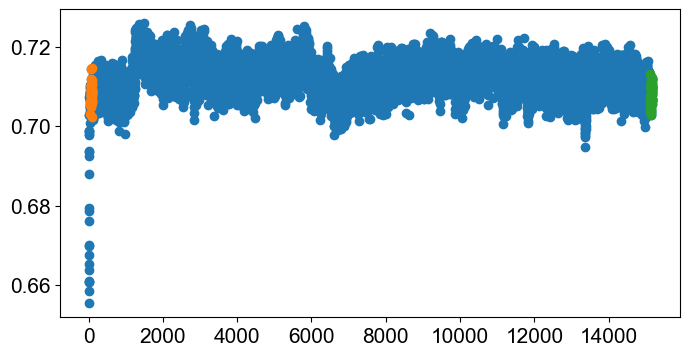

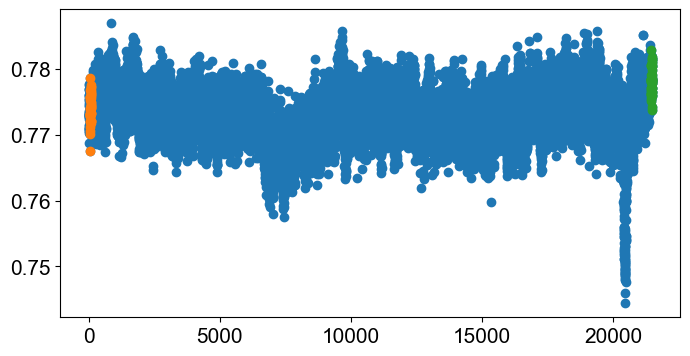

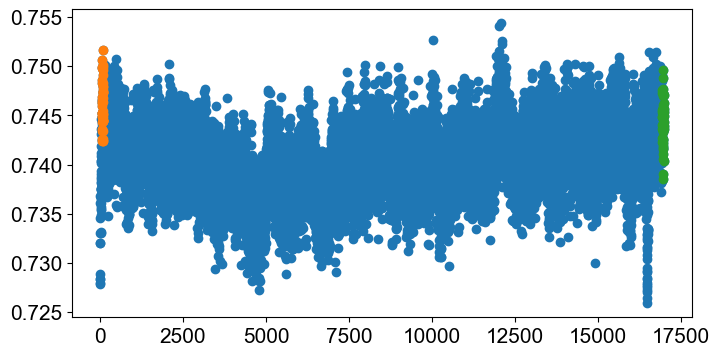

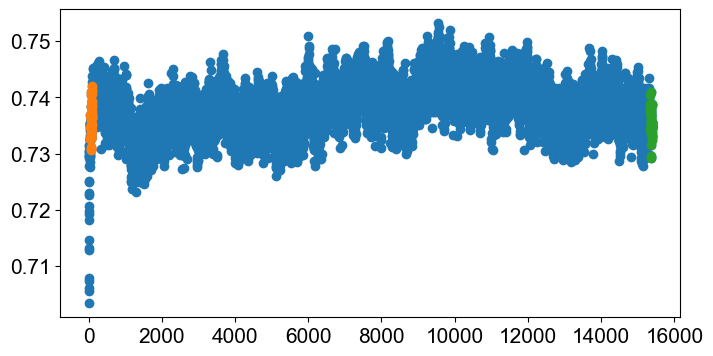

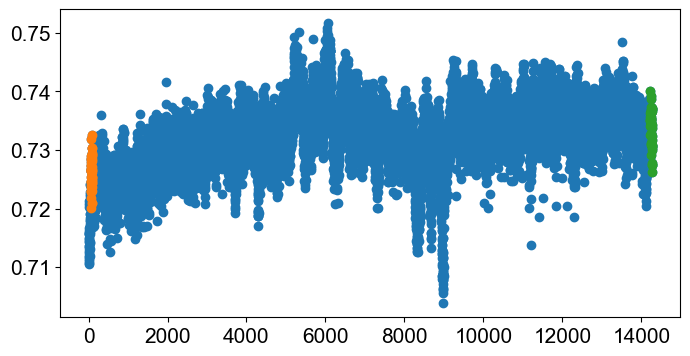

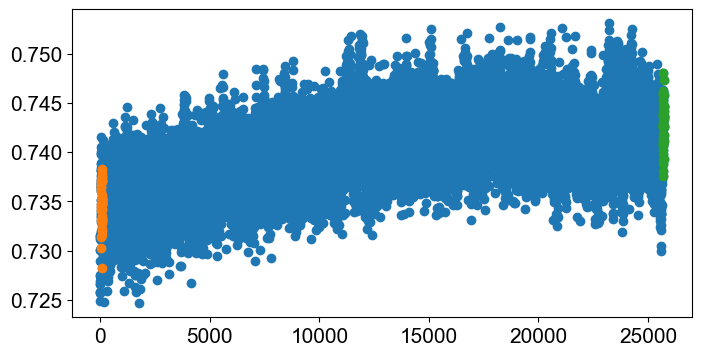

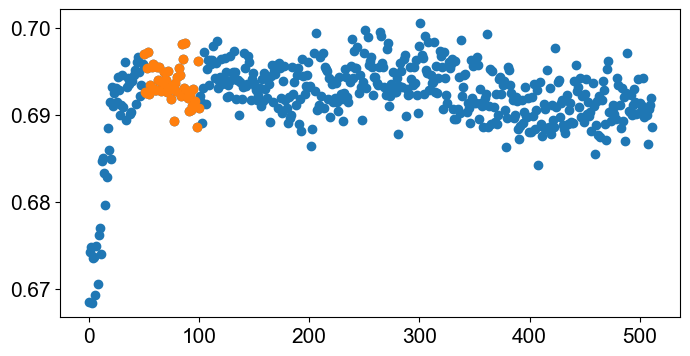

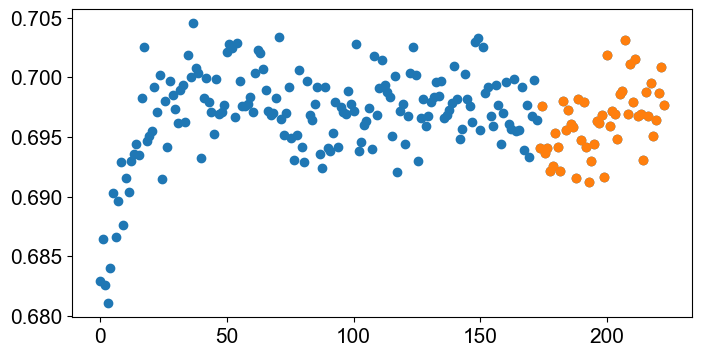

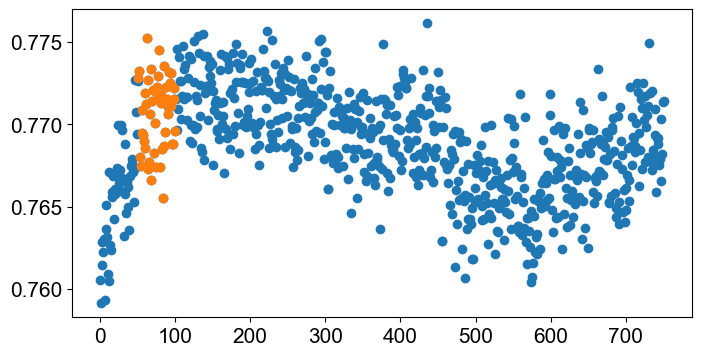

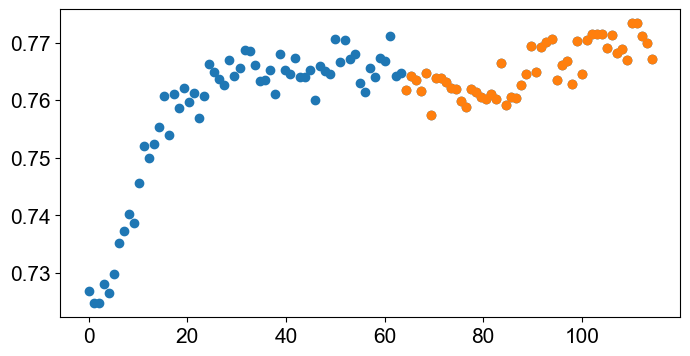

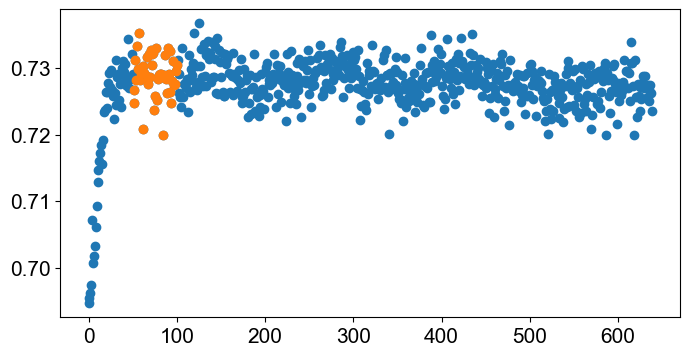

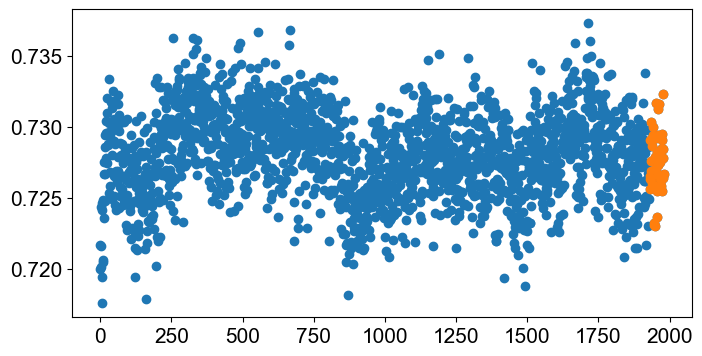

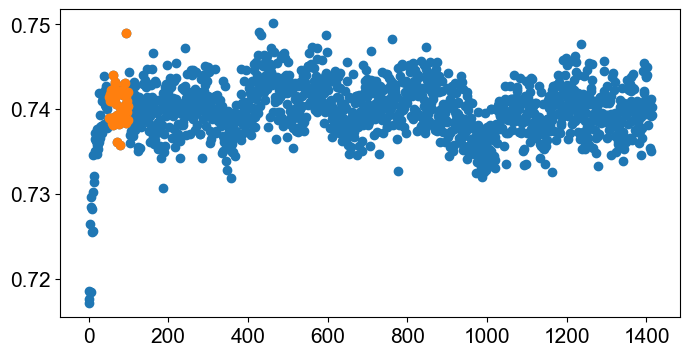

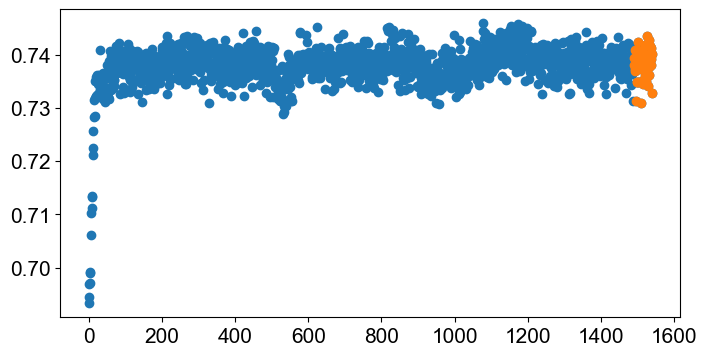

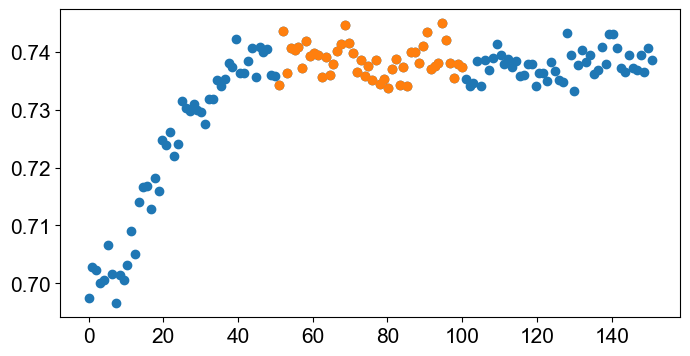

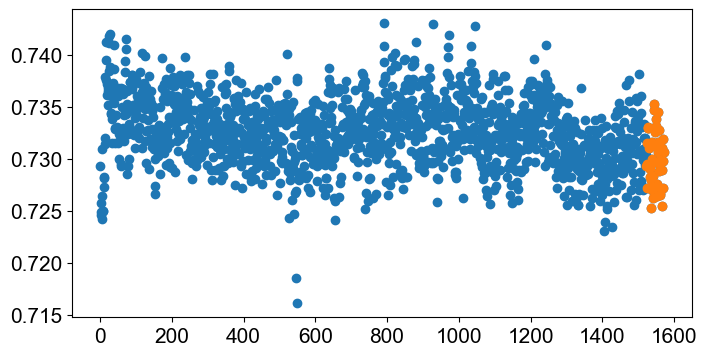

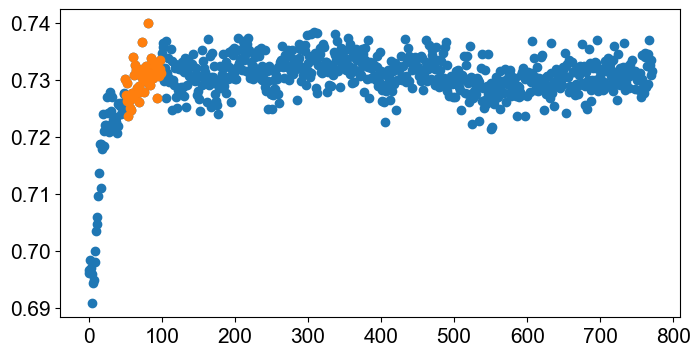

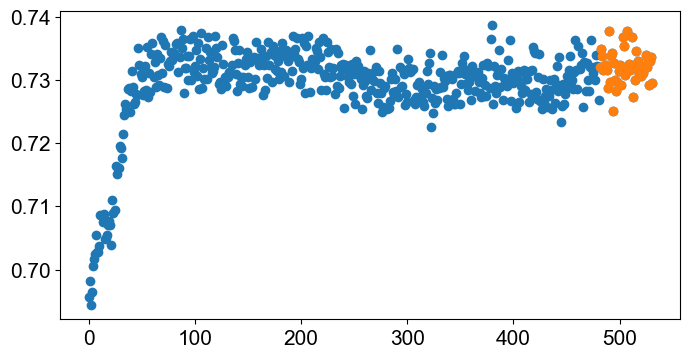

In [4]:
SD_WakeData = {}
window_size = 50
start_buffer = 50
for FLP_exp, e, m in zip(FLP_classes_dict[0]['Experiment Classes'], FLP_classes_dict[0]['Experiment Names'], 
                         FLP_classes_dict[0]['Animal Names']):
    fig, ax = plt.subplots(figsize = [8,4])
    SD_WakeData[e] = {}
    t, lft, zt, idx_vals = find_sd_bout(FLP_exp)
    SD_WakeData[e]['Start Val'] = np.mean(lft[(t > start_buffer) & (t < start_buffer+window_size)])
    SD_WakeData[e]['End Val'] = np.mean(lft[t > t[-1]-window_size])
    SD_WakeData[e]['Mouse ID'] = m
    SD_WakeData[e]['AmpChange'] = SD_WakeData[e]['End Val']-SD_WakeData[e]['Start Val']
    SD_WakeData[e]['Lifetime Vals'] = lft
    SD_WakeData[e]['Time Vals'] = zt
    ax.scatter(t, lft)
    ax.scatter(t[(t > start_buffer) & (t < start_buffer+window_size)], lft[(t > start_buffer) & (t < start_buffer+window_size)])
    ax.scatter(t[t > t[-1]-window_size], lft[t > t[-1]-window_size])

Cntrl_WakeData = {}
ZT_start = 4
ZT_end = 8
for FLP_exp, e, m in zip(FLP_classes_dict[1]['Experiment Classes'], FLP_classes_dict[1]['Experiment Names'], 
                         FLP_classes_dict[1]['Animal Names']):
    Cntrl_WakeData[e] = {'Start Val':[], 'End Val':[], 'Mouse ID':m}
    cir_start_idx, _ = find_zt_window_start(FLP_exp, ZT_start, ZT_end, prefer_occurrence=1, gap_threshold=100)

    fig, ax = plt.subplots(figsize = [8,4])
    LFTdict = PKA.LFTvals_byState(FLP_exp, FLP_exp.ss_onset_offset(), 
                                  time_range = [FLP_exp.Time[cir_start_idx],FLP_exp.Time[cir_start_idx]+3600*4])
    wake_lengths = np.array([t[-1]-t[0] for t in LFTdict['Time']['Wake']])
    this_wake = np.where(wake_lengths > window_size+start_buffer)[0][0]
    lft = LFTdict['Lifetime']['FLIM-mAKAR']['Wake'][this_wake]
    t = LFTdict['Time']['Wake'][this_wake]-LFTdict['Time']['Wake'][this_wake][0]
    Cntrl_WakeData[e]['Start Val'].append(np.mean(lft[(t > start_buffer) & (t < start_buffer+window_size)]))
    ax.scatter(t, lft)
    ax.scatter(t[(t > start_buffer) & (t < start_buffer+window_size)], lft[(t > start_buffer) & (t < start_buffer+window_size)])

    fig, ax = plt.subplots(figsize = [8,4])
    LFTdict = PKA.LFTvals_byState(FLP_exp, FLP_exp.ss_onset_offset(), 
                                  time_range = [FLP_exp.Time[cir_start_idx],FLP_exp.Time[cir_start_idx]+3600*4])
    wake_lengths = np.array([t[-1]-t[0] for t in LFTdict['Time']['Wake']])
    this_wake = np.where(wake_lengths > window_size+start_buffer)[0][-1]
    lft = LFTdict['Lifetime']['FLIM-mAKAR']['Wake'][this_wake]
    t = LFTdict['Time']['Wake'][this_wake]-LFTdict['Time']['Wake'][this_wake][0]       
    Cntrl_WakeData[e]['End Val'].append(np.mean(lft[t > t[-1]-window_size]))
    ax.scatter(t, lft)
    ax.scatter(t[t > t[-1]-window_size], lft[t > t[-1]-window_size])
    Cntrl_WakeData[e]['AmpChange'] = [e-s for s,e in zip(Cntrl_WakeData[e]['Start Val'], Cntrl_WakeData[e]['End Val'])]
    

Results_ByAnimal = {}
for m in np.unique(np.concatenate(mouse_names)):
    Results_ByAnimal[m] = {'SD':[SD_WakeData[e]['AmpChange'] for e in SD_WakeData.keys() if SD_WakeData[e]['Mouse ID'] == m],
                           'Cntrl': [Cntrl_WakeData[e]['AmpChange'] for e in Cntrl_WakeData.keys() if Cntrl_WakeData[e]['Mouse ID'] == m]}
                        

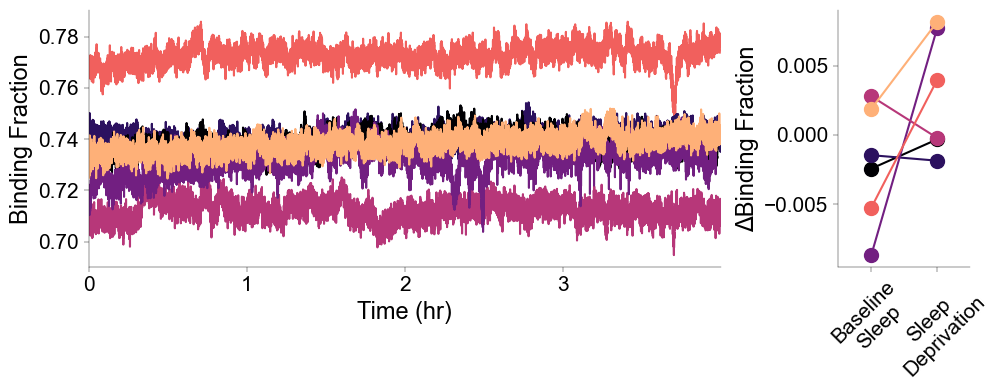

In [7]:
# fig, ax = plt.subplots(figsize = [4,6])
fig = plt.figure(figsize = [10,4])
ax1 = plt.subplot2grid(shape=(1, 4), loc=(0, 0), colspan=3, rowspan = 1)
ax2 = plt.subplot2grid(shape=(1, 4), loc=(0, 3), colspan=1, rowspan = 1)
fig_savedir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_6'
color_list = graph.get_colormap(len(Results_ByAnimal.keys())+1, cmap_name = 'magma')
color_dict = dict(zip(Results_ByAnimal.keys(), color_list))
for e in SD_WakeData.keys():
    # ax1.scatter(SD_WakeData[e]['Time Vals'], SD_WakeData[e]['Lifetime Vals'], color = color_dict[SD_WakeData[e]['Mouse ID']], 
    #             s = 5)
    plot_idx, = np.where(SD_WakeData[e]['Time Vals'] < 20)
    ax1.plot(SD_WakeData[e]['Time Vals'][plot_idx]-SD_WakeData[e]['Time Vals'][plot_idx][0], SD_WakeData[e]['Lifetime Vals'][plot_idx], 
             color = color_dict[SD_WakeData[e]['Mouse ID']])
for i, m in enumerate(Results_ByAnimal.keys()):
    ax2.plot([0,1], [np.mean(Results_ByAnimal[m]['Cntrl']),np.mean(Results_ByAnimal[m]['SD'])], color = color_dict[m], 
            marker = 'o', markersize = 10)
graph.label_axes(ax2, y = 'ΔBinding Fraction')
graph.label_axes(ax1, y = 'Binding Fraction', x = 'Time (hr)')
graph.thick_axes(fig, [ax1, ax2], width = 0.3)
ax1.set_xlim([0,4])
ax1.set_xticks(np.arange(0, ax1.get_xlim()[-1]))
# ax1.set_xticklabels(np.arange(0, ax1.get_xlim()[-1]/3600))
ax2.set_xlim([-0.5, 1.5])
ax2.set_xticks([0,1])
ax2.set_xticklabels(['Baseline\nSleep', 'Sleep\nDeprivation'], rotation= 45)
fig.tight_layout()
fig.savefig(os.path.join(fig_savedir, 'wake_change_amp.ps'))

In [23]:
fig_savedir

'/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_6'